In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd
import simpy

In [2]:
DAYS_PER_MONTH = 30

In [3]:
class GasMarket:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario

        self.storage = scenario.get("initial_storage", 3000)  # Bcf
        self.storage_capacity = scenario.get("storage_capacity", 4200)
        self.max_injection = scenario.get("max_injection", 300)  # Bcf/month
        self.max_withdrawal = scenario.get("max_withdrawal", 500)

        self.base_price = scenario.get("base_price", 3.00)  # $/MMBtu
        self.price = self.base_price

        self.history = []

    def supply(self, price):
        """
        Simplified upward-sloping supply curve.
        """
        base_supply = self.scenario.get("base_supply", 3100)  # Bcf/month
        elasticity = self.scenario.get("supply_elasticity", 120)

        shock = self.scenario.get("supply_shock", 0)
        return max(0, base_supply + elasticity * (price - self.base_price) + shock)

    def demand(self, month, price):
        """
        Demand = residential/commercial seasonal + industrial + power + LNG.
        """
        base_demand = self.scenario.get("base_demand", 2900)

        # Winter demand peaks in Jan/Feb/Dec; summer power demand rises in Jul/Aug
        winter_factor = [
            1.35,
            1.25,
            1.05,
            0.85,
            0.75,
            0.80,
            0.95,
            1.00,
            0.85,
            0.90,
            1.05,
            1.30,
        ][month % 12]

        weather_shock = random.gauss(
            self.scenario.get("weather_mean", 0),
            self.scenario.get("weather_volatility", 80),
        )

        lng_exports = self.scenario.get("lng_exports", 400)
        industrial = self.scenario.get("industrial_demand", 700)

        price_elasticity = self.scenario.get("demand_elasticity", -90)

        return max(
            0,
            base_demand * winter_factor
            + industrial
            + lng_exports
            + weather_shock
            + price_elasticity * (price - self.base_price),
        )

    def pipeline_constraint(self, raw_supply):
        """
        Represents transmission bottlenecks.
        """
        pipeline_capacity = self.scenario.get("pipeline_capacity", 3400)
        return min(raw_supply, pipeline_capacity)

    def clear_market(self, month):
        """
        Simple iterative price-clearing rule.
        Raises price if demand exceeds available supply + storage withdrawal.
        Lowers price if supply exceeds demand + injection capacity.
        """
        price = self.price

        for _ in range(40):
            raw_supply = self.supply(price)
            delivered_supply = self.pipeline_constraint(raw_supply)
            demand = self.demand(month, price)

            imbalance = demand - delivered_supply

            if imbalance > 0:
                withdrawal = min(imbalance, self.storage, self.max_withdrawal)
                net_shortage = imbalance - withdrawal
            else:
                injection = min(
                    -imbalance, self.storage_capacity - self.storage, self.max_injection
                )
                net_shortage = imbalance + injection

            if abs(net_shortage) < 10:
                break

            price += 0.002 * net_shortage
            price = max(0.50, price)

        return price

    def monthly_step(self, month):
        price = self.clear_market(month)

        raw_supply = self.supply(price)
        delivered_supply = self.pipeline_constraint(raw_supply)
        demand = self.demand(month, price)

        imbalance = delivered_supply - demand

        if imbalance > 0:
            storage_change = min(
                imbalance, self.storage_capacity - self.storage, self.max_injection
            )
        else:
            storage_change = -min(-imbalance, self.storage, self.max_withdrawal)

        self.storage += storage_change
        self.price = price

        self.history.append(
            {
                "month": month + 1,
                "price": round(price, 2),
                "raw_supply_bcf": round(raw_supply, 1),
                "delivered_supply_bcf": round(delivered_supply, 1),
                "demand_bcf": round(demand, 1),
                "storage_bcf": round(self.storage, 1),
                "storage_change_bcf": round(storage_change, 1),
                "pipeline_capacity_bcf": self.scenario.get("pipeline_capacity", 3400),
                "lng_exports_bcf": self.scenario.get("lng_exports", 400),
            }
        )


In [4]:
def market_process(env, market, months):
    for month in range(months):
        market.monthly_step(month)
        yield env.timeout(DAYS_PER_MONTH)

In [5]:
def run_scenario(name, scenario, months=24, seed=42):
    random.seed(seed)

    env = simpy.Environment()
    market = GasMarket(env, scenario)
    env.process(market_process(env, market, months))
    env.run(until=months * DAYS_PER_MONTH)

    df = pd.DataFrame(market.history)
    df["scenario"] = name
    return df

In [6]:
# -------------------------
# Example scenarios
# -------------------------

reference = {
    "base_price": 3.00,
    "base_supply": 3100,
    "base_demand": 2900,
    "industrial_demand": 700,
    "lng_exports": 400,
    "pipeline_capacity": 3400,
    "initial_storage": 3200,
    "storage_capacity": 4200,
    "supply_elasticity": 120,
    "demand_elasticity": -90,
    "weather_volatility": 80,
}

cold_winter = {
    **reference,
    "weather_mean": 150,
}

lng_growth = {
    **reference,
    "lng_exports": 750,
}

pipeline_constraint = {
    **reference,
    "pipeline_capacity": 3000,
}

supply_shock = {
    **reference,
    "supply_shock": -350,
}


results = pd.concat(
    [
        run_scenario("Reference", reference),
        run_scenario("Cold winter", cold_winter),
        run_scenario("Higher LNG exports", lng_growth),
        run_scenario("Pipeline constraint", pipeline_constraint),
        run_scenario("Supply shock", supply_shock),
    ]
)

In [7]:
print(results.head(12))
print("\nAverage price by scenario:")
print(results.groupby("scenario")["price"].mean().sort_values(ascending=False))


    month  price  raw_supply_bcf  delivered_supply_bcf  demand_bcf  \
0       1  14.87          4524.0                3400.0      3865.8   
1       2  14.87          4524.0                3400.0      3761.9   
2       3  14.77          4512.6                3400.0      2969.3   
3       4   8.08          3709.3                3400.0      3161.1   
4       5   5.77          3432.2                3400.0      3076.9   
5       6   5.77          3432.2                3400.0      3222.9   
6       7   5.77          3432.2                3400.0      3555.7   
7       8   5.77          3432.2                3400.0      3713.3   
8       9   5.77          3432.2                3400.0      3295.9   
9      10   5.77          3432.2                3400.0      3395.3   
10     11   5.77          3432.2                3400.0      3957.4   
11     12  13.94          4412.9                3400.0      3840.4   

    storage_bcf  storage_change_bcf  pipeline_capacity_bcf  lng_exports_bcf  \
0        2

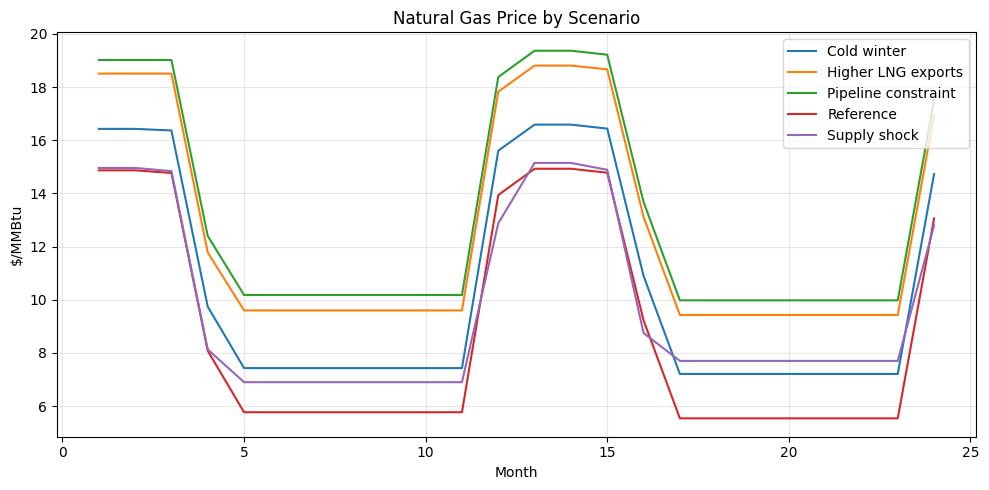

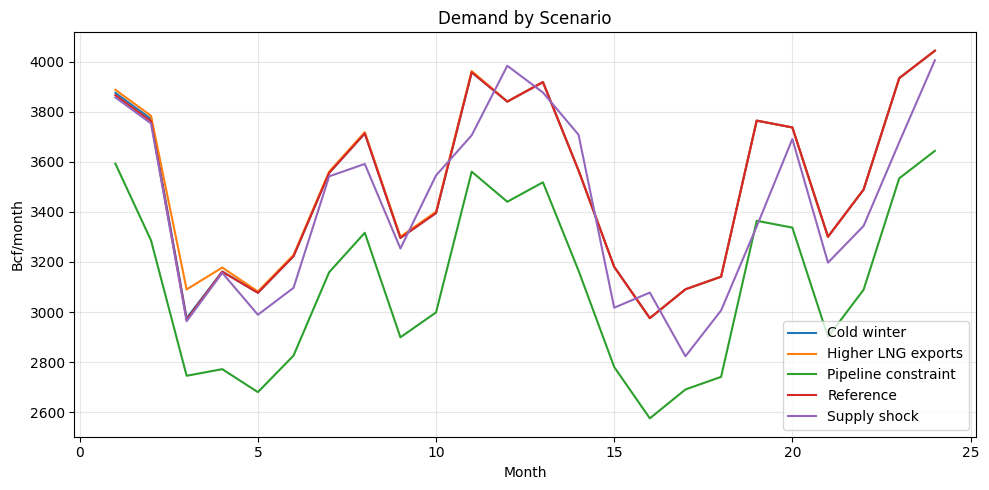

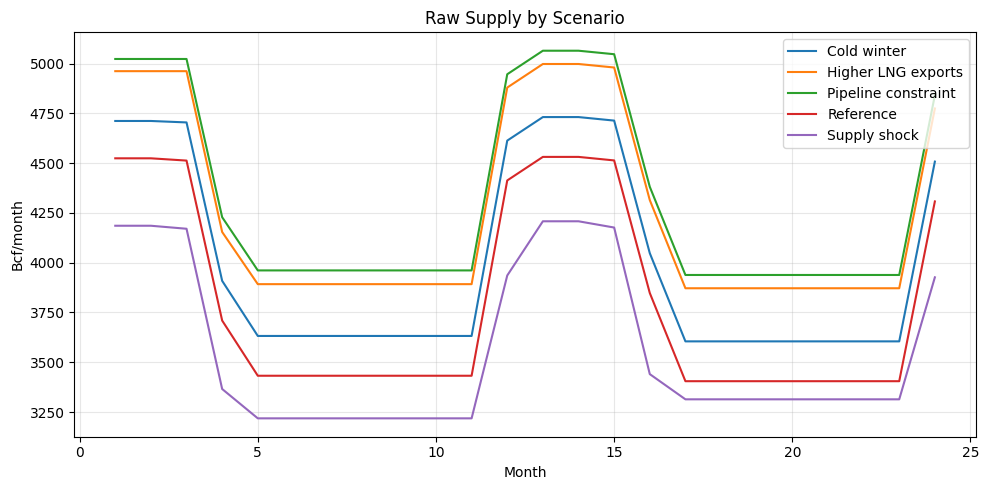

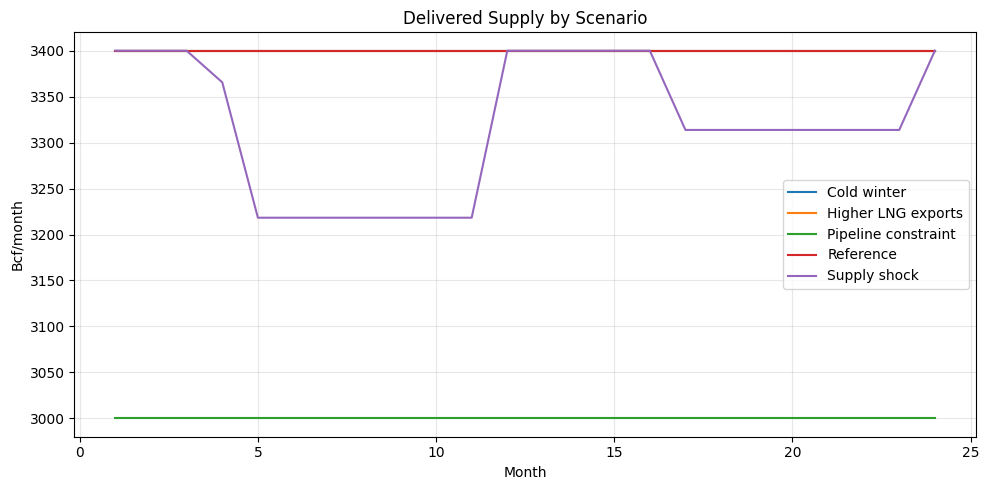

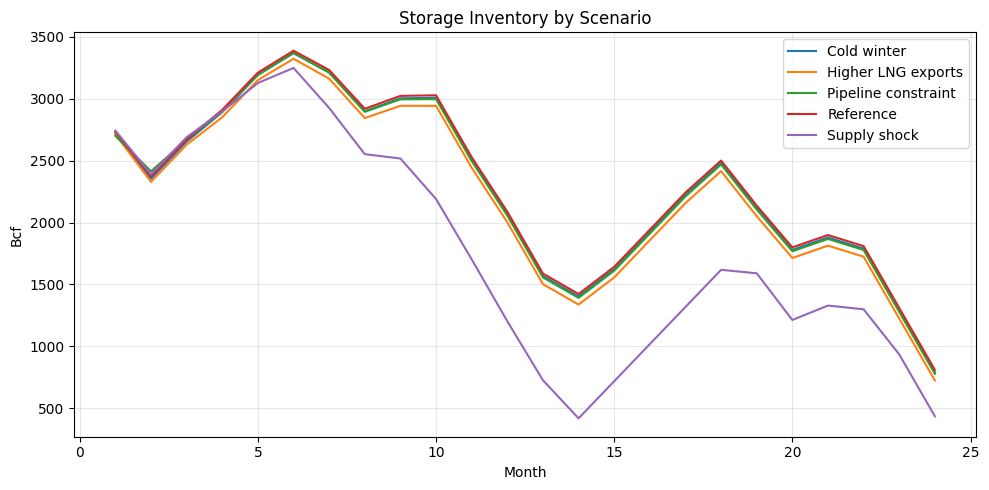

In [ ]:
def plot_metric(results, metric, ylabel=None, title=None):
    pivot = results.pivot(index="month", columns="scenario", values=metric)

    plt.figure(figsize=(10, 5))
    for scenario in pivot.columns:
        plt.plot(pivot.index, pivot[scenario], label=scenario)

    plt.xlabel("Month")
    plt.ylabel(ylabel or metric)
    plt.title(title or metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# 1. Market price
plot_metric(results, "price", ylabel="$/MMBtu", title="Natural Gas Price by Scenario")

# 2. Demand
plot_metric(results, "demand_bcf", ylabel="Bcf/month", title="Demand by Scenario")

# 3. Raw supply
plot_metric(
    results, "raw_supply_bcf", ylabel="Bcf/month", title="Raw Supply by Scenario"
)

# 4. Delivered supply after pipeline constraints
plot_metric(
    results,
    "delivered_supply_bcf",
    ylabel="Bcf/month",
    title="Delivered Supply by Scenario",
)

# 5. Storage level
plot_metric(results, "storage_bcf", ylabel="Bcf", title="Storage Inventory by Scenario")

# 6. Storage injections / withdrawals
plot_metric(
    results,
    "storage_change_bcf",
    ylabel="Bcf/month",
    title="Monthly Storage Change by Scenario",
)

# 7. Pipeline capacity
plot_metric(
    results,
    "pipeline_capacity_bcf",
    ylabel="Bcf/month",
    title="Pipeline Capacity by Scenario",
)

# 8. LNG exports
plot_metric(
    results, "lng_exports_bcf", ylabel="Bcf/month", title="LNG Exports by Scenario"
)
